### 부모님의 최종학력과 나의 수입간의 상관관계 파악

In [59]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'   # 한글 폰트
mpl.rcParams['axes.unicode_minus'] = False      # 마이너스 깨짐 방지
# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스 기호 꺠짐 방지
plt.rcParams["axes.unicode_minus"] = False



In [60]:
# 부모님 교육수준(부) : np2006_39
# 부모님 교육수준(모) : np2006_40
# 부모님 직업(부) : np2006_41
# 부모님 직업(모) : np2006_42
# 월급 : p2002_8aq1

In [61]:
# 데이터 출처 : (2025년 20차 한국복지패널조사
df = pd.read_spss('data/Koweps_hpwc20_2025_beta1.sav')
raw_data = df.copy()

In [62]:
data = df.rename(columns={
    'np2006_39' : 'father_edu_level',
    'np2006_40' : 'mother_edu_level',
    'p2002_8aq1' : 'income'
    
})

In [63]:
# 필요한 컬럼만 
data = data[['father_edu_level','mother_edu_level','income']]

# 결측치 제거
data = data.dropna(subset=['father_edu_level','mother_edu_level','income'])

# 모름응답 결측치 제거
data = data[
    (data["father_edu_level"] != 9) &
    (data["mother_edu_level"] != 9)
]

In [64]:
# 숫자로 표현된 최종학력을 한글로 변환 하는 딕셔너리
edu_map = {
    1: "무학",
    2: "서당수학",
    3: "초등학교졸",
    4: "중학교졸",
    5: "고등학교졸",
    6: "전문대졸",
    7: "대학교졸",
    8: "대학원졸"
}


In [65]:
data[['income', 'father_edu_level', 'mother_edu_level']].corr(numeric_only=True)

,income,father_edu_level,mother_edu_level
income,1.000000,0.017532,0.017814
father_edu_level,0.017532,1.000000,0.774800
mother_edu_level,0.017814,0.774800,1.000000


In [66]:

data["father_edu_name"] = data["father_edu_level"].replace(edu_map)
data["mother_edu_name"] = data["mother_edu_level"].replace(edu_map)


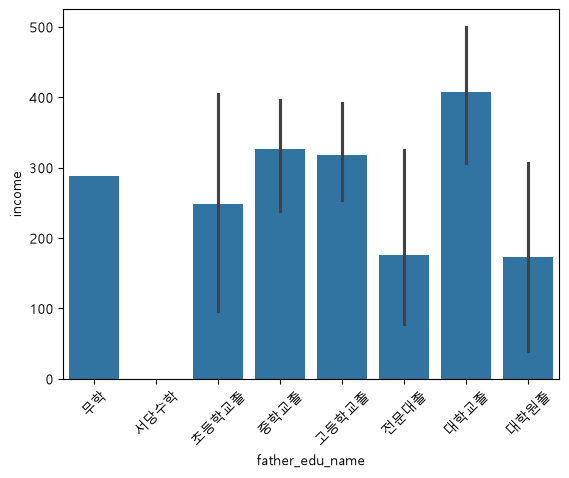

In [68]:
order = [
    "무학",
    "서당수학",
    "초등학교졸",
    "중학교졸",
    "고등학교졸",
    "전문대졸",
    "대학교졸",
    "대학원졸"
]

sns.barplot(x="father_edu_name", y="income",data= data, order=order)
plt.xticks(rotation= 45)
plt.show()

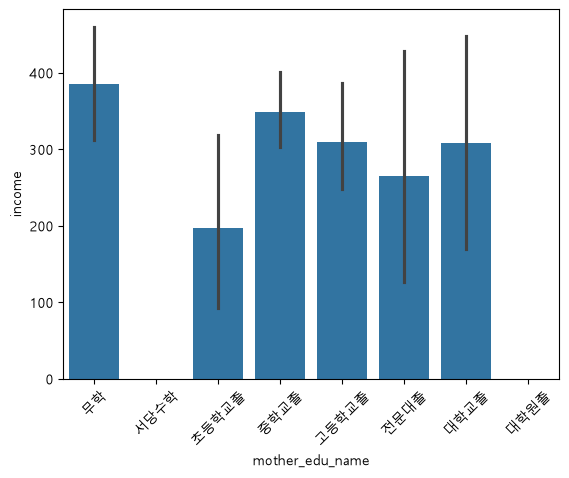

In [69]:
sns.barplot(x="mother_edu_name", y="income",data=data,order = order)
plt.xticks(rotation= 45)
plt.show()

<Axes: >

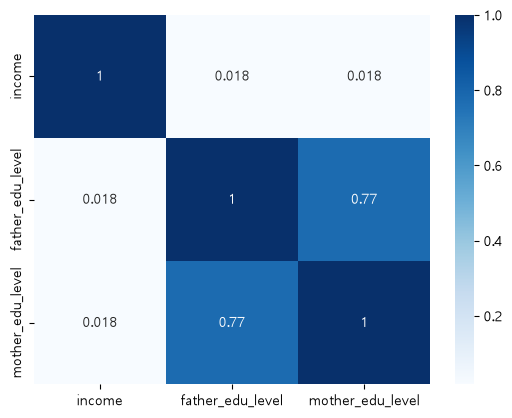

In [70]:
corr = data[['income','father_edu_level','mother_edu_level']].corr()

sns.heatmap(corr, annot=True, cmap='Blues')

# 이원분산분석

In [1]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [75]:
mapping = {
    1: "초등 이하",
    2: "초등 이하",
    3: "초등 이하",
    4: "중졸",
    5: "고졸",
    6: "대졸 이상",
    7: "대졸 이상",
    8: "대졸 이상"
}

data["father_group"] = data["father_edu_level"].map(mapping)
data["mother_group"] = data["mother_edu_level"].map(mapping)

**귀무가설**  
부의 학력: 부의 학력에 따라 자녀의 평균 소득은 차이가 없다.  
모의 학력: 모의 학력에 따라 자녀의 평균 소득은 차이가 없다.  
부 + 모: 부와 모의 학력 조합에 따른 추가적인 효과는 없다.  

In [38]:
model = ols(
    'income ~ C(father_group) + C(mother_group) + C(father_group):C(mother_group)',
    data=data
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                                       sum_sq    df         F    PR(>F)
C(father_group)                  2.031513e+04   3.0  0.176126  0.838975
C(mother_group)                  1.049243e+04   3.0  0.090966  0.913183
C(father_group):C(mother_group)  5.454279e+05   9.0  1.576227  0.193299
Residual                         2.153100e+06  56.0       NaN       NaN


c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [56]:
print(df.shape)
print(data.shape)

(14915, 834)
(66, 5)
